# PCA-Enhanced Customer Segmentation for Credit Card Marketing

## Load data + header + describe

In [1]:
import pandas as pd
import numpy as np

# Display options (optional)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Load data
df = pd.read_csv("CC_GENERAL.csv")   # if your file is in the same folder as the notebook
# df = pd.read_csv("/mnt/data/CC_GENERAL.csv")  # (optional) if you use this exact path in this environment

# Print header
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [2]:
# Summary statistics
df.describe()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Column meanings

- **CUST_ID**: Unique customer identifier (categorical ID, not a behavior feature).
- **BALANCE**: Average balance amount on the account.
- **BALANCE_FREQUENCY**: Frequency of balance updates (how often balance changes/updates).
- **PURCHASES**: Total amount of purchases made.
- **ONEOFF_PURCHASES**: Total amount of one-off (single, non-installment) purchases.
- **INSTALLMENTS_PURCHASES**: Total amount of installment purchases.
- **CASH_ADVANCE**: Total amount of cash advances taken by the customer.
- **PURCHASES_FREQUENCY**: Frequency of purchases (0 = never, 1 = very frequent).
- **ONEOFF_PURCHASES_FREQUENCY**: Frequency of one-off purchases.
- **PURCHASES_INSTALLMENTS_FREQUENCY**: Frequency of installment purchases.
- **CASH_ADVANCE_FREQUENCY**: Frequency of cash advances.
- **CASH_ADVANCE_TRX**: Number of cash advance transactions.
- **PURCHASES_TRX**: Number of purchase transactions.
- **CREDIT_LIMIT**: Customer credit limit.
- **PAYMENTS**: Total amount of payments made by the customer.
- **MINIMUM_PAYMENTS**: Total minimum payment amount due/paid (depends on dataset definition).
- **PRC_FULL_PAYMENT**: Percentage of months in which the customer paid the full balance.
- **TENURE**: Number of months the customer has been a credit card user.

## Observations from summary statistics

- Many monetary variables (e.g., PURCHASES, CASH_ADVANCE) are highly skewed with large maximum values, suggesting the presence of outliers and very different spending behaviors.
- Several features can contain many zeros (e.g., CASH_ADVANCE, PRC_FULL_PAYMENT), meaning many customers never use those behaviors. This can create distinct customer segments.
- TENURE is often near the maximum value (commonly 12 months in this dataset), so it may have limited power to separate customers, but it may still help distinguish newer vs. long-term users.
- These statistics are useful for understanding scale, outliers, and sparsity, and they motivate scaling and dimensionality reduction (PCA) before clustering.


## Data types + missing values + duplicates

In [ ]:
# Data types and missing values
df.info()


In [ ]:
# Missing values per column
df.isna().sum().sort_values(ascending=False)


In [ ]:
# Duplicate rows
df.duplicated().sum()


## Clean dataset (no missing, no duplicates, correct dtypes)

In [3]:
df_clean = df.copy()

# 1) Drop duplicate rows (if any)
df_clean = df_clean.drop_duplicates()

# 2) Fix missing values using median (robust to outliers)
for col in ["MINIMUM_PAYMENTS", "CREDIT_LIMIT"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 3) (Optional) Ensure numeric columns are numeric (usually already correct)
# Example: force TENURE to int
df_clean["TENURE"] = df_clean["TENURE"].astype(int)

# Verify cleaning
print("Missing values (max):", df_clean.isna().sum().max())
print("Duplicates:", df_clean.duplicated().sum())
df_clean.info()


Missing values (max): 0
Duplicates: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX               

## Data Structure and Cleaning Summary

### Dataset Overview

- The dataset contains **8,950 customers**.
- There are **18 columns** in total.
- Data types:
  - 14 float64 features
  - 3 int64 features
  - 1 object feature (`CUST_ID`)
- Memory usage is approximately **1.2 MB**, which is manageable for clustering analysis.

### Missing Values

Using `DataFrame.info()` and `isna().sum()`, we confirmed that:

- All columns have **8,950 non-null values**
- The maximum number of missing values in any column is **0**

Therefore, **no imputation was required**.

### Duplicate Records

Using `DataFrame.duplicated().sum()`, we confirmed that:

- Number of duplicate rows: **0**

Therefore, no rows needed to be removed.

### Data Types

- `CUST_ID` is an object (string) identifier and does not represent customer behavior.
- All other columns are numeric (float64 or int64), which is appropriate for clustering.
- Since clustering algorithms require numerical input, the dataset is already correctly formatted for modeling.

### Cleaning Actions Taken

- Verified there are no missing values.
- Verified there are no duplicate rows.
- Confirmed numeric data types are appropriate.
- No imputation or row removal was necessary.

The dataset is clean and ready for feature analysis and dimensionality reduction.


## Drop CUST_ID + correlation heatmap + pairplot

In [4]:
X = df_clean.drop(columns=["CUST_ID"])
X.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


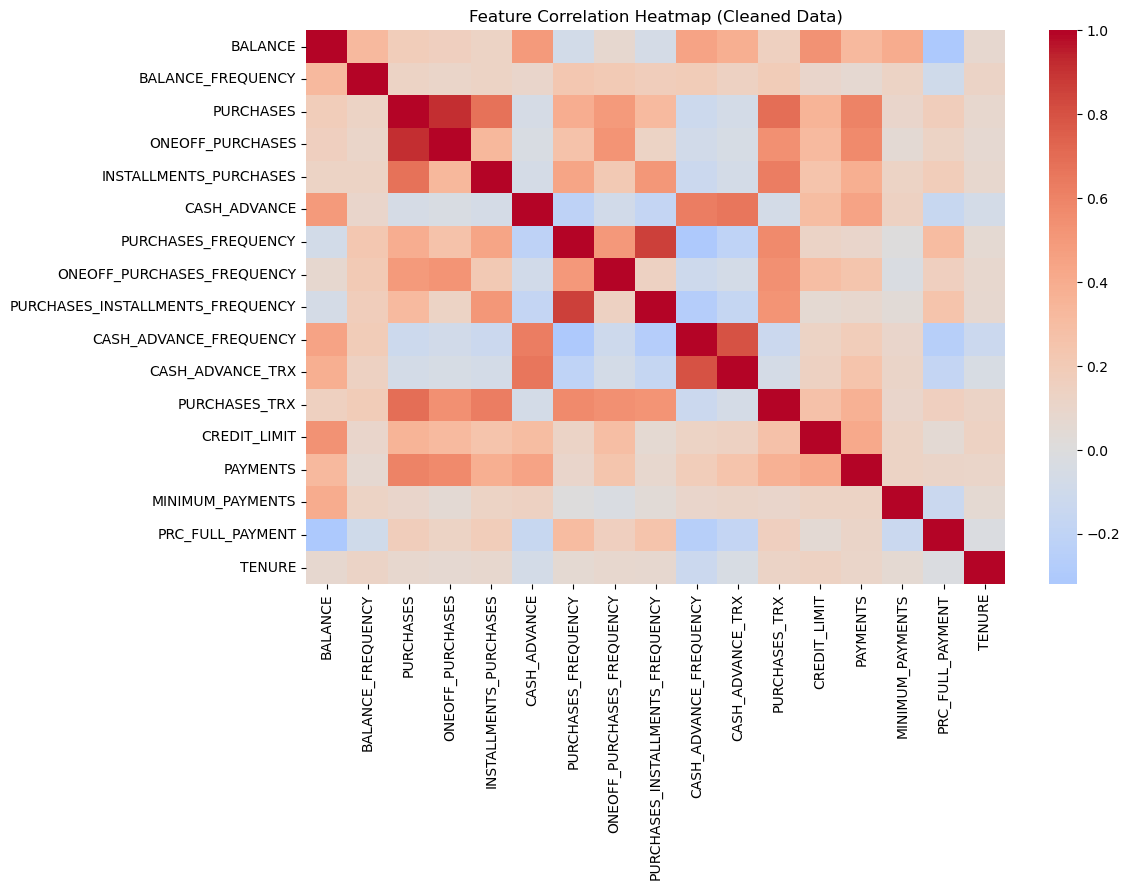

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap (Cleaned Data)")
plt.tight_layout()
plt.show()


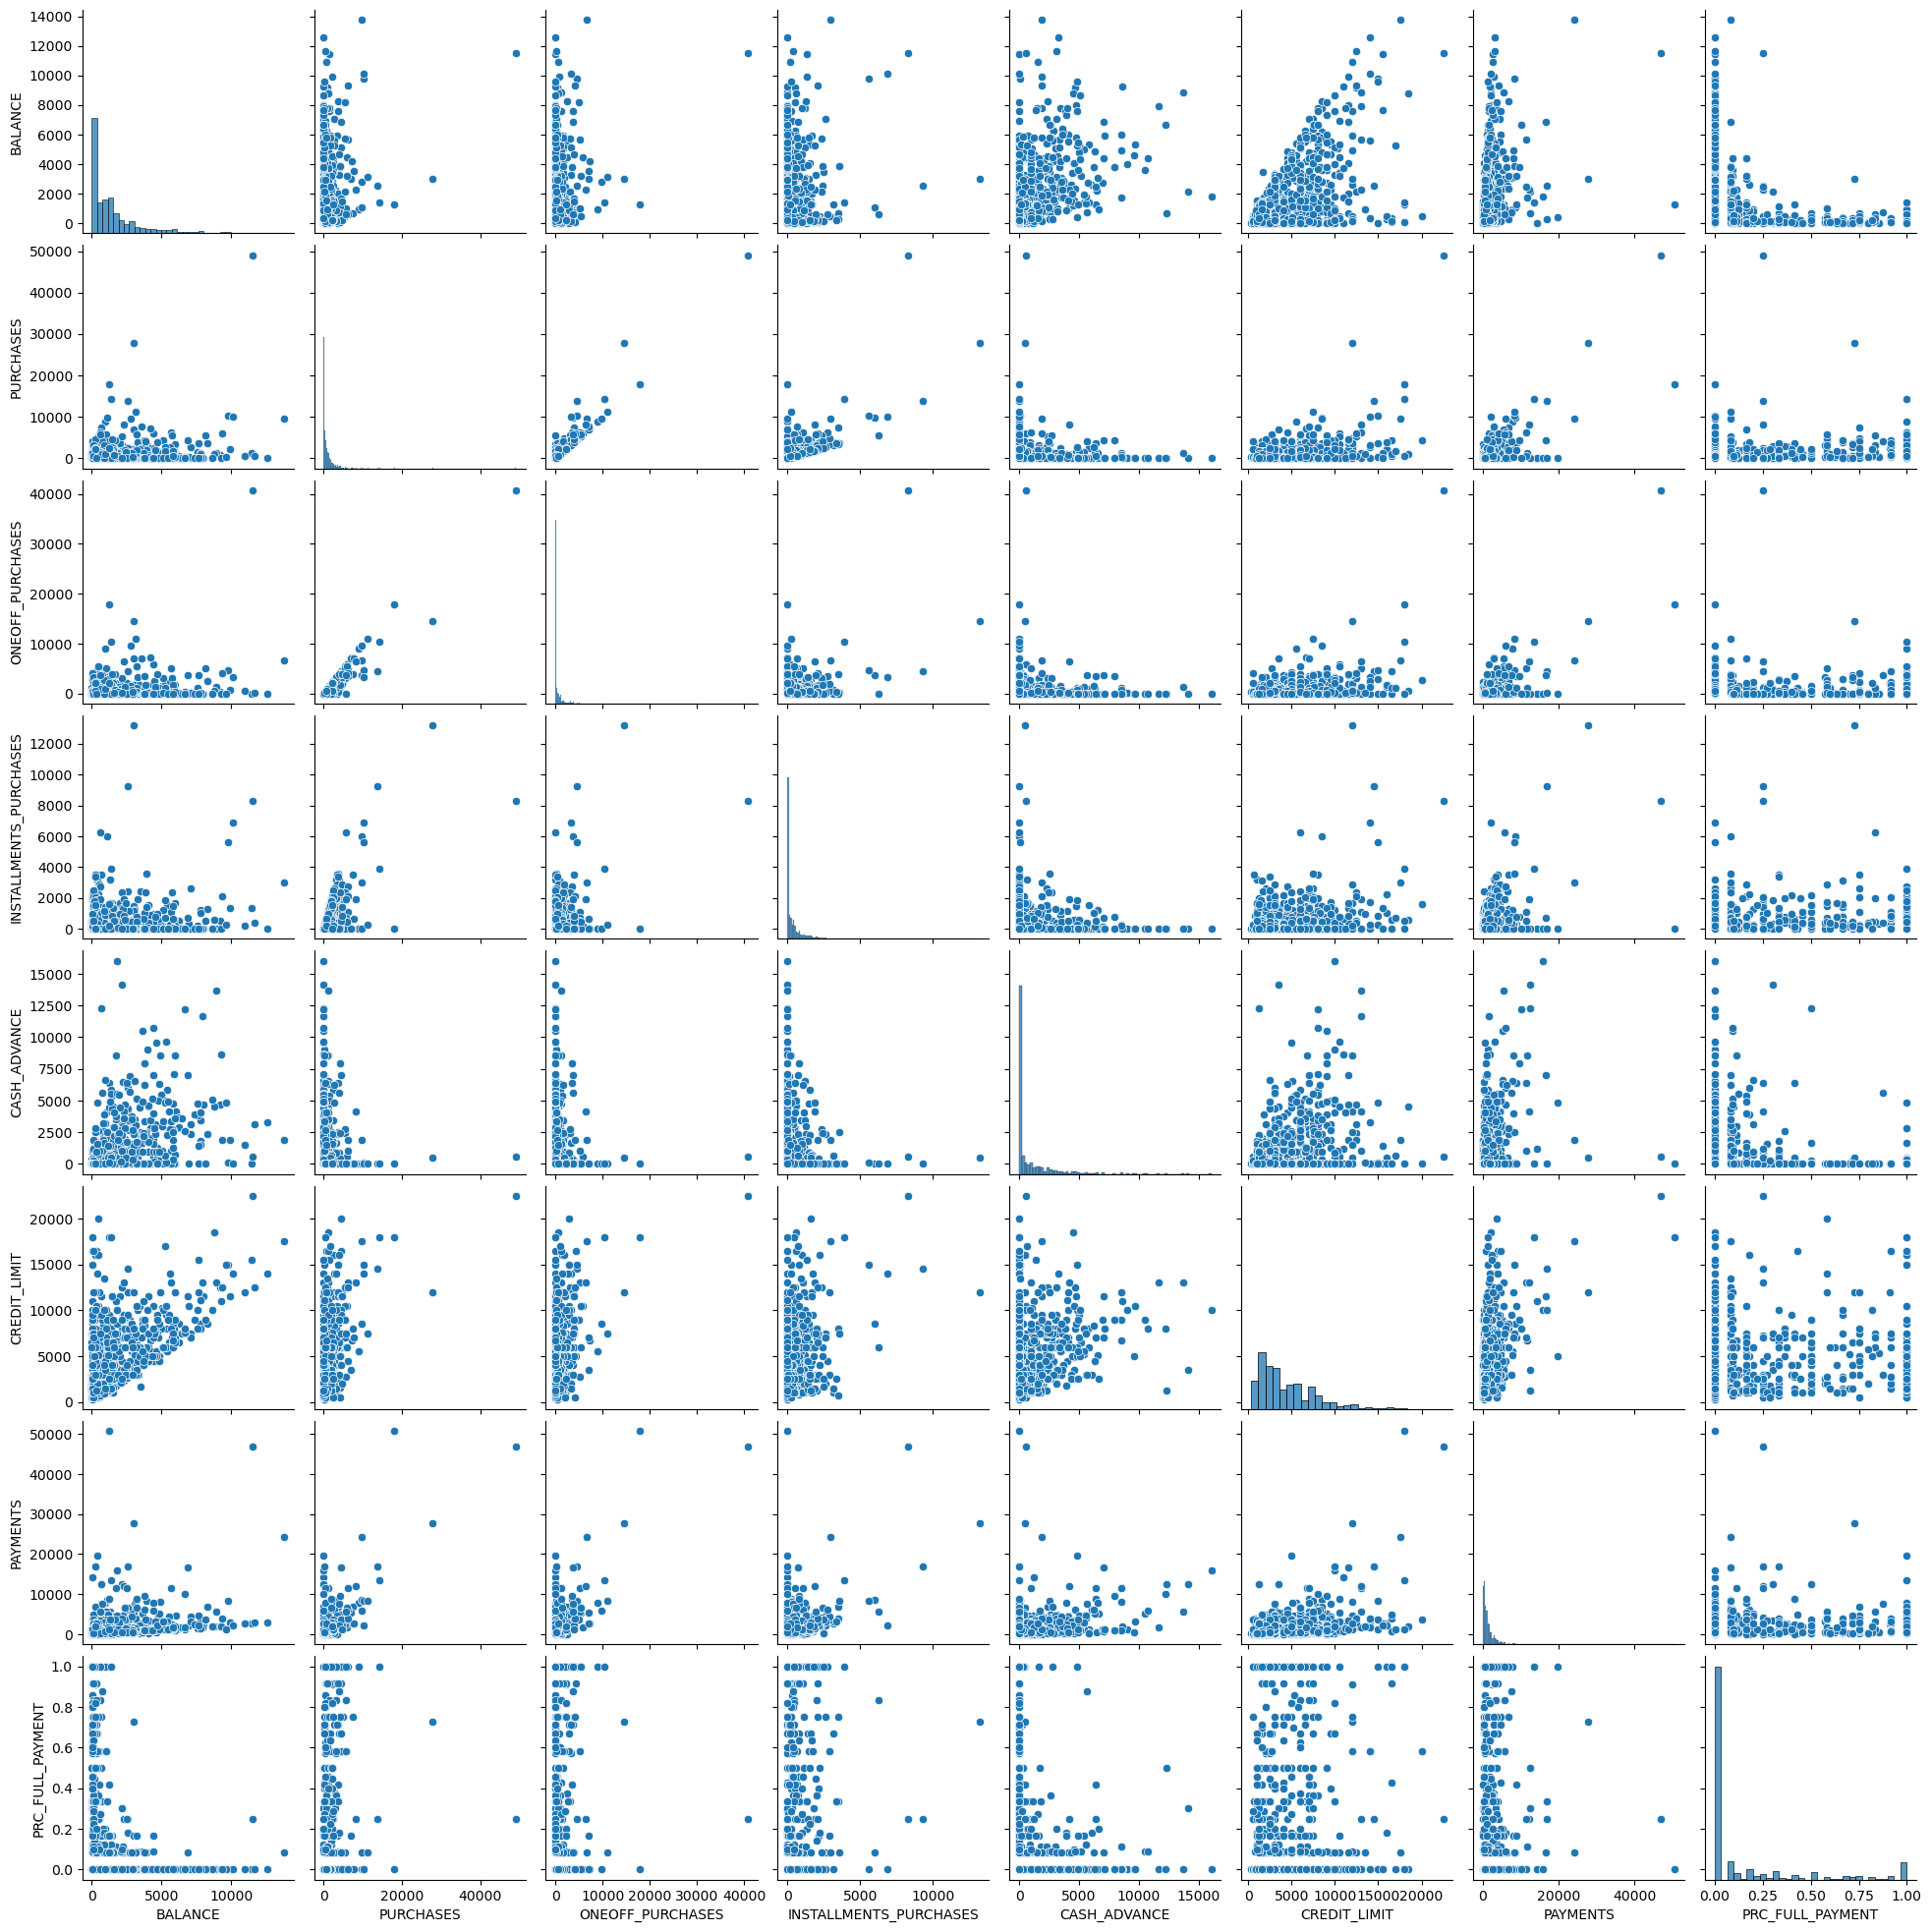

In [6]:
# Pairplot can be very slow with 8950 rows x many columns.
# Use a sample + a subset of important features.
sample = X.sample(n=min(1000, len(X)), random_state=42)

pairplot_cols = [
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "PRC_FULL_PAYMENT"
]

sns.pairplot(sample[pairplot_cols], diag_kind="hist")
plt.show()


## Observations from Correlation Heatmap and Pairplot

The correlation heatmap shows several clear patterns:

- Strong positive correlations exist among purchase-related variables (`PURCHASES`, `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`, `PURCHASES_TRX`). This indicates redundancy and overlapping information.
- Cash advance variables (`CASH_ADVANCE`, `CASH_ADVANCE_FREQUENCY`, `CASH_ADVANCE_TRX`) are highly correlated, suggesting a distinct behavioral dimension.
- `CREDIT_LIMIT`, `BALANCE`, and `PAYMENTS` show moderate positive relationships, indicating higher-limit customers tend to spend and pay more.
- `PRC_FULL_PAYMENT` is negatively correlated with balance and cash advance behavior, suggesting more financially responsible customers.

From the pairplot:

- Most monetary features are heavily right-skewed, with many low-activity customers and a few extreme outliers.
- Clear linear relationships are visible between purchase amounts and transaction counts, as well as between cash advance amounts and transactions.
- Distinct behavioral regions are observable (e.g., high purchase vs. high cash advance customers), indicating natural customer segments may exist.

Overall, the dataset contains correlated features and skewed distributions, supporting the use of scaling and PCA before clustering to reduce multicollinearity and improve cluster separation.


In [7]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Initialize scaler
scaler = MinMaxScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Print header
X_scaled_df.head()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0.002148,0.818182,0.001945,0.000000,0.00424,0.000000,0.166667,0.000000,0.083333,0.000000,0.00000,0.005587,0.031720,0.003979,0.001826,0.000000,1.0
1,0.168169,0.909091,0.000000,0.000000,0.00000,0.136685,0.000000,0.000000,0.000000,0.166667,0.03252,0.000000,0.232053,0.080893,0.014034,0.222222,1.0
2,0.131026,1.000000,0.015766,0.018968,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.033520,0.248748,0.012264,0.008210,0.000000,1.0
3,0.087521,0.636364,0.030567,0.036775,0.00000,0.004366,0.083333,0.083333,0.000000,0.055555,0.00813,0.002793,0.248748,0.000000,0.004088,0.000000,1.0
4,0.042940,1.000000,0.000326,0.000393,0.00000,0.000000,0.083333,0.083333,0.000000,0.000000,0.00000,0.002793,0.038397,0.013374,0.003204,0.000000,1.0


## Feature Scaling Results (MinMaxScaler)

After applying `MinMaxScaler`, all features were successfully transformed to the range [0, 1].

From the transformed header:

- All monetary variables (e.g., BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT) are now normalized.
- Frequency-based variables are also scaled consistently.
- TENURE appears mostly as 0 or 1 after scaling, indicating limited variation in this feature.
- No negative values remain.
- The relative relationships between customers are preserved, but magnitude differences are removed.

Scaling is essential because clustering algorithms (especially K-Means and DBSCAN) rely on distance calculations. Without normalization, large-scale variables such as CREDIT_LIMIT or PURCHASES would dominate the clustering process.

The dataset is now properly scaled and ready for PCA transformation.


In [8]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

# PCA without specifying number of components (keeps all)
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled_df)

# Explained variance ratios
evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# Print explained variance ratios (rounded)
evr_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(evr))],
    "Explained_Variance_Ratio": evr,
    "Cumulative_Explained_Variance": cum_evr
})

# Show first rows (all PCs exist, but this is readable)
evr_df.head(10)


,PC,Explained_Variance_Ratio,Cumulative_Explained_Variance
0,PC1,0.495971,0.495971
1,PC2,0.140541,0.636512
2,PC3,0.128446,0.764958
3,PC4,0.076769,0.841727
4,PC5,0.069636,0.911362
5,PC6,0.035883,0.947245
6,PC7,0.018193,0.965438
7,PC8,0.013529,0.978967
8,PC9,0.006555,0.985522
9,PC10,0.005509,0.991030


In [9]:
# How many components to retain at least 95% variance?
n_95 = int(np.argmax(cum_evr >= 0.95) + 1)

print("Explained variance ratios (first 10 PCs):")
print(np.round(evr[:10], 4))

print("\nCumulative explained variance (first 10 PCs):")
print(np.round(cum_evr[:10], 4))

print(f"\nNumber of components needed to retain >= 95% variance: {n_95}")
print(f"Cumulative variance at PC{n_95}: {cum_evr[n_95-1]:.4f}")


Explained variance ratios (first 10 PCs):
[0.496  0.1405 0.1284 0.0768 0.0696 0.0359 0.0182 0.0135 0.0066 0.0055]

Cumulative explained variance (first 10 PCs):
[0.496  0.6365 0.765  0.8417 0.9114 0.9472 0.9654 0.979  0.9855 0.991 ]

Number of components needed to retain >= 95% variance: 7
Cumulative variance at PC7: 0.9654


## PCA Explained Variance Analysis

PCA was applied to the scaled dataset without specifying `n_components`, allowing all principal components to be computed.

### Key Results

- **PC1 alone explains 49.6%** of the total variance.
- The first **3 components explain 76.5%** of the variance.
- The first **5 components explain 91.1%** of the variance.
- The first **7 components explain 96.54%** of the variance.

To retain at least **95% of the total variance**, **7 principal components** are required.

### Interpretation

This indicates that the original 17 features can be effectively reduced to **7 components** while preserving most of the information in the dataset.

The strong contribution of PC1 suggests that a dominant behavioral dimension exists in the data, likely capturing overall spending or credit usage behavior.

The dataset is therefore suitable for dimensionality reduction before clustering.


In [11]:
from sklearn.decomposition import PCA
import pandas as pd

# PCA retaining 95% variance
pca_95 = PCA(n_components=0.95)

X_pca_95 = pca_95.fit_transform(X_scaled_df)

# Number of components retained
print("Number of components selected:", pca_95.n_components_)

# Create new DataFrame
pc_columns = [f"PC{i+1}" for i in range(pca_95.n_components_)]
X_pca_95_df = pd.DataFrame(X_pca_95, columns=pc_columns)

# Print header
X_pca_95_df.head()


Number of components selected: 7


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-0.482168,-0.097653,-0.046473,-0.058293,0.109979,-0.171672,0.018602
1,-0.608575,-0.019376,0.082109,-0.218748,-0.099024,0.137029,0.047467
2,0.304508,0.920934,0.012204,0.160033,0.162325,-0.158527,-0.006547
3,-0.588622,-0.005631,0.037055,0.004430,0.223708,0.065366,0.096132
4,-0.554357,0.052978,-0.084182,-0.132827,-0.017081,-0.204461,0.056412


## PCA Transformation (95% Variance Retained)

PCA was performed using `n_components=0.95`, allowing the algorithm to automatically retain enough components to preserve at least 95% of the total variance.

The model selected **7 principal components**, reducing the original 17 scaled features to 7 dimensions.

The transformed dataset now consists of:

- PC1 to PC7
- Each component is a linear combination of the original features
- Values are centered around 0 (PCA components are mean-centered)

This transformation:

- Removes multicollinearity between highly correlated features
- Compresses redundant information
- Reduces dimensionality by ~60%
- Improves computational efficiency for clustering
- Enables clearer visualization in reduced dimensions

The dataset `X_pca_95_df` will now be used for clustering analysis.


In [15]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

X_clust = X_pca_95_df.values
n_samples = X_clust.shape[0]

results = []

def safe_silhouette(X, labels):
    """Compute silhouette only if there are at least 2 clusters and no single-label case."""
    uniq = np.unique(labels)
    if len(uniq) < 2:
        return np.nan
    return silhouette_score(X, labels)

# -------------------
# 1) K-Means (4 models)
# -------------------
for k in [3, 4, 5, 6]:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_clust)

    sil = safe_silhouette(X_clust, labels)

    results.append({
        "Model": f"KMeans (k={k})",
        "Algorithm": "KMeans",
        "Clusters": len(np.unique(labels)),
        "Noise_Points": 0,
        "Noise_Ratio": 0.0,
        "Silhouette": sil,
        "Adjusted_Score": sil  # no noise penalty needed
    })

# -------------------
# 2) Hierarchical (4 models)
# -------------------
hier_configs = [
    (3, "ward"),
    (4, "ward"),
    (5, "average"),
    (5, "complete")
]

for k, linkage in hier_configs:
    if linkage == "ward":
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    else:
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage, metric="euclidean")

    labels = model.fit_predict(X_clust)
    sil = safe_silhouette(X_clust, labels)

    results.append({
        "Model": f"Agglomerative ({linkage}, k={k})",
        "Algorithm": "Hierarchical",
        "Clusters": len(np.unique(labels)),
        "Noise_Points": 0,
        "Noise_Ratio": 0.0,
        "Silhouette": sil,
        "Adjusted_Score": sil
    })

# -------------------
# 3) DBSCAN (4+ models)
# -------------------
dbscan_configs = [
    (0.30, 5),
    (0.35, 5),
    (0.40, 5),
    (0.45, 6),
]

for eps, min_samples in dbscan_configs:
    model = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean")
    labels = model.fit_predict(X_clust)

    noise_points = int(np.sum(labels == -1))
    noise_ratio = noise_points / n_samples

    # silhouette on non-noise points only
    mask = labels != -1
    labels_core = labels[mask]
    X_core = X_clust[mask]

    # number of clusters excluding noise
    uniq = set(labels)
    n_clusters = len(uniq) - (1 if -1 in uniq else 0)

    if n_clusters >= 2:
        sil = silhouette_score(X_core, labels_core)
    else:
        sil = np.nan

    # penalize models with too much noise
    adj = sil * (1 - noise_ratio) if not np.isnan(sil) else np.nan

    results.append({
        "Model": f"DBSCAN (eps={eps}, min={min_samples})",
        "Algorithm": "DBSCAN",
        "Clusters": n_clusters,
        "Noise_Points": noise_points,
        "Noise_Ratio": noise_ratio,
        "Silhouette": sil,
        "Adjusted_Score": adj
    })

# -------------------
# Result table
# -------------------
results_df = pd.DataFrame(results)

# Pretty formatting (optional)
results_df["Noise_Ratio"] = results_df["Noise_Ratio"].round(4)
results_df["Silhouette"] = results_df["Silhouette"].round(4)
results_df["Adjusted_Score"] = results_df["Adjusted_Score"].round(4)

# Sort by Adjusted score (recommended when DBSCAN is included)
results_df_sorted = results_df.sort_values(by="Adjusted_Score", ascending=False)

results_df_sorted


,Model,Algorithm,Clusters,Noise_Points,Noise_Ratio,Silhouette,Adjusted_Score
0,KMeans (k=3),KMeans,3,0,0.0000,0.3837,0.3837
3,KMeans (k=6),KMeans,6,0,0.0000,0.3515,0.3515
2,KMeans (k=5),KMeans,5,0,0.0000,0.3363,0.3363
1,KMeans (k=4),KMeans,4,0,0.0000,0.3361,0.3361
6,"Agglomerative (average, k=5)",Hierarchical,5,0,0.0000,0.3131,0.3131
4,"Agglomerative (ward, k=3)",Hierarchical,3,0,0.0000,0.3093,0.3093
5,"Agglomerative (ward, k=4)",Hierarchical,4,0,0.0000,0.2626,0.2626
7,"Agglomerative (complete, k=5)",Hierarchical,5,0,0.0000,0.2175,0.2175
9,"DBSCAN (eps=0.35, min=5)",DBSCAN,3,75,0.0084,0.1795,0.1780
8,"DBSCAN (eps=0.3, min=5)",DBSCAN,3,149,0.0166,0.0886,0.0871


## Clustering Experiments and Model Comparison

A total of 12 clustering models were created using:

- **K-Means** (k = 3–6)
- **Hierarchical (Agglomerative)** with different linkage strategies (ward, average, complete)
- **DBSCAN** with varying `eps` and `min_samples`

All models were trained on the 7-component PCA dataset.

### Evaluation Method

For each model:

- Cluster labels were generated.
- The **silhouette score** was computed to evaluate cluster cohesion and separation.
- For DBSCAN, noise points (label = -1) were excluded from silhouette calculation.
- The **noise ratio** (percentage of noise points) was recorded.
- An **Adjusted Score = Silhouette × (1 − Noise Ratio)** was calculated to penalize models with excessive noise.

### Results Summary

- **Best Model: KMeans (k=3)**
  - Silhouette Score: **0.3837**
  - Noise Ratio: 0
- KMeans models consistently outperformed Hierarchical and DBSCAN.
- Hierarchical clustering produced moderate separation (max ≈ 0.3131).
- DBSCAN produced lower silhouette scores and, in some cases, collapsed into a single cluster or generated excessive noise.

### Interpretation

KMeans (k=3) provides:

- The highest silhouette score,
- No noise points,
- Stable and well-separated clusters.

DBSCAN was not suitable for this dataset, as density-based separation was weak and cluster structure appears more globular than density-defined.

Therefore, **KMeans (k=3)** is selected as the optimal clustering model for further customer segmentation analysis.



### Comparison with Assignment 2

In Assignment 2, the best model was:

- Model: **Agglomerative (ward, k=4)**
- Silhouette Score: **0.2546**

Comparing the two results:

- Assignment 2 best score: **0.2546**
- Current best score: **0.3837**
- Improvement: **+0.1291**

This represents a substantial improvement in cluster separation and cohesion.


### PCA Improve Performance

Applying PCA before clustering:

- Reduced multicollinearity among highly correlated features
- Compressed redundant information into principal components
- Removed noise from less informative dimensions
- Improved cluster compactness in transformed space

By reducing the dataset from 17 features to 7 principal components while retaining 96.5% of the variance, the clustering algorithm was able to detect clearer structure in the data.


### Final Conclusion

The application of PCA significantly improved clustering quality.  
Therefore, **KMeans (k=3)** on the PCA-transformed dataset is the most appropriate model for customer segmentation in this use case.


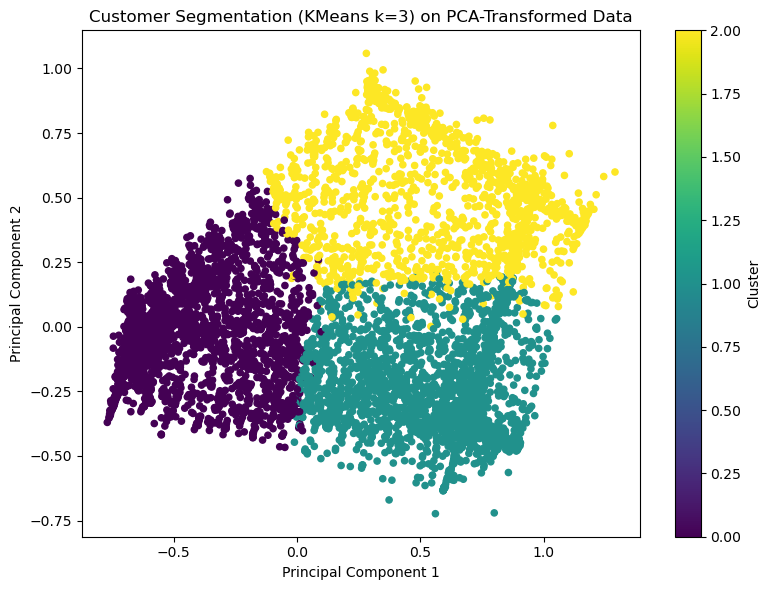

In [16]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Refit best model to get labels
best_model = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = best_model.fit_predict(X_pca_95_df)

# Scatter plot of first two principal components
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca_95_df["PC1"],
    X_pca_95_df["PC2"],
    c=cluster_labels,
    cmap="viridis",
    s=20
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation (KMeans k=3) on PCA-Transformed Data")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()


## Scatter Plot of PCA Components (PC1 vs PC2)

The scatter plot displays customers in the space of the first two principal components, colored by KMeans (k=3) cluster assignments.

### Observations

- Three clearly distinguishable clusters are visible.
- Cluster separation occurs primarily along **Principal Component 1**, which appears to capture the dominant spending or credit usage dimension.
- One cluster is positioned on the left side (lower PC1 values), while two clusters occupy the right side but are separated vertically along PC2.
- The clusters are compact and show limited overlap, indicating strong internal cohesion and good separation.
- The structure appears triangular, suggesting distinct behavioral segments rather than gradual transitions.

### Comparison with Assignment 2

In Assignment 2, clustering was performed on the original scaled features without PCA. The 2D visualization showed more overlap between groups, and boundaries were less clearly defined.

After applying PCA:

- The dimensionality was reduced from 17 features to 7 principal components.
- Correlated features were compressed into orthogonal dimensions.
- Cluster separation became visually clearer.
- The silhouette score improved from **0.2546** (Assignment 2) to **0.3837**, confirming better cluster structure.

Overall, the PCA transformation significantly enhanced both visual interpretability and clustering quality.


Cluster 0: 4728 customers
Cluster 1: 2786 customers
Cluster 2: 1436 customers


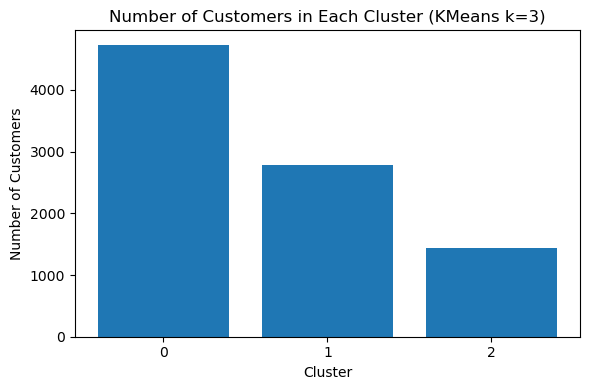

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Refit best model to ensure consistency
from sklearn.cluster import KMeans
best_model = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = best_model.fit_predict(X_pca_95_df)

# Count customers in each cluster
unique, counts = np.unique(cluster_labels, return_counts=True)

# Print counts
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} customers")

# Plot histogram
plt.figure(figsize=(6,4))
plt.bar(unique, counts)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster (KMeans k=3)")
plt.xticks(unique)
plt.tight_layout()
plt.show()


## Cluster Size Distribution

The histogram shows the number of customers assigned to each cluster under KMeans (k=3):

- Cluster 0: 4,728 customers (~52.8%)
- Cluster 1: 2,786 customers (~31.1%)
- Cluster 2: 1,436 customers (~16.0%)

### Observations

- Cluster 0 represents the largest segment, containing slightly more than half of the customer base.
- Cluster 1 represents a medium-sized segment.
- Cluster 2 is the smallest segment but still contains a substantial number of customers.

Importantly, no cluster is extremely small or negligible. Even the smallest cluster (16%) represents a meaningful portion of customers.

### Interpretation

The cluster sizes appear reasonable and business-relevant:

- The segmentation captures a dominant mainstream customer group (Cluster 0).
- It identifies a moderate secondary segment (Cluster 1).
- It isolates a distinct smaller segment (Cluster 2), which may represent high-value or behaviorally unique customers.

The distribution is not overly skewed, suggesting that KMeans (k=3) produced stable and meaningful segmentation rather than artificial micro-clusters.

Overall, the cluster sizes make practical sense for marketing strategy design, as each segment is large enough to justify targeted campaigns.


In [18]:
# Make a copy of cleaned original data (before scaling and PCA)
df_original = df_clean.copy()

# Add cluster labels from best model
df_original["Cluster"] = cluster_labels

df_original.head()


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,0
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0


In [19]:
cluster_0 = df_original[df_original["Cluster"] == 0]
cluster_1 = df_original[df_original["Cluster"] == 1]
cluster_2 = df_original[df_original["Cluster"] == 2]

print("Cluster 0 size:", len(cluster_0))
print("Cluster 1 size:", len(cluster_1))
print("Cluster 2 size:", len(cluster_2))


Cluster 0 size: 4728
Cluster 1 size: 2786
Cluster 2 size: 1436


In [20]:
print("===== Cluster 0 Summary =====")
display(cluster_0.describe())

print("===== Cluster 1 Summary =====")
display(cluster_1.describe())

print("===== Cluster 2 Summary =====")
display(cluster_2.describe())


===== Cluster 0 Summary =====


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
count,4728.000000,4728.000000,4728.000000,4728.000000,4728.00000,4728.000000,4728.000000,4728.000000,4728.000000,4728.000000,4728.000000,4728.000000,4728.000000,4728.000000,4728.000000,4728.000000,4728.000000,4728.0
mean,1705.353844,0.826169,296.110013,232.907862,63.39110,1356.571768,0.143562,0.081561,0.060843,0.185721,4.420051,2.680838,4145.263934,1477.335898,824.941667,0.068362,11.447335,0.0
std,2059.673948,0.276716,824.357238,712.946591,410.75464,2352.179433,0.168386,0.124714,0.120438,0.213489,7.776410,4.921284,3348.756515,2653.629608,2106.398220,0.190037,1.402413,0.0
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.037744,0.000000,6.000000,0.0
25%,198.917637,0.727273,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1500.000000,316.507437,185.164394,0.000000,12.000000,0.0
50%,1082.054640,1.000000,54.760000,0.000000,0.00000,378.962318,0.083333,0.000000,0.000000,0.090909,2.000000,1.000000,3000.000000,676.820723,353.159236,0.000000,12.000000,0.0
75%,2285.202744,1.000000,320.000000,205.852500,10.12250,1817.958912,0.250000,0.100000,0.083333,0.272727,6.000000,4.000000,6000.000000,1541.426625,792.422506,0.000000,12.000000,0.0
max,16304.889250,1.000000,22500.000000,22101.780000,22500.00000,47137.211760,0.666667,0.583333,0.500000,1.500000,123.000000,186.000000,23000.000000,50721.483360,61031.618600,1.000000,12.000000,0.0


===== Cluster 1 Summary =====


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
count,2786.000000,2786.000000,2786.000000,2786.000000,2786.000000,2786.000000,2786.000000,2786.000000,2786.000000,2786.000000,2786.000000,2786.000000,2786.000000,2786.000000,2786.000000,2786.000000,2786.000000,2786.0
mean,1138.840613,0.914410,1076.213112,275.007943,801.848844,502.190212,0.871642,0.099976,0.821061,0.070666,1.731874,20.984207,3939.993891,1402.219236,918.125869,0.238506,11.517229,1.0
std,1807.093596,0.190398,1262.707218,601.840674,941.070058,1483.401147,0.161024,0.149155,0.188338,0.155152,4.869821,21.341031,3223.595798,2017.789471,2999.113842,0.340232,1.372161,0.0
min,0.000000,0.000000,12.000000,0.000000,12.000000,0.000000,0.416667,0.000000,0.333333,0.000000,0.000000,0.000000,300.000000,0.000000,0.019163,0.000000,6.000000,1.0
25%,58.855452,0.909091,336.000000,0.000000,279.670000,0.000000,0.750000,0.000000,0.666667,0.000000,0.000000,10.000000,1500.000000,374.550186,155.588851,0.000000,12.000000,1.0
50%,340.657756,1.000000,638.025000,0.000000,502.970000,0.000000,1.000000,0.000000,0.888889,0.000000,0.000000,13.000000,3000.000000,785.697845,203.166010,0.000000,12.000000,1.0
75%,1412.701812,1.000000,1348.235000,270.272500,993.007500,94.941622,1.000000,0.166667,1.000000,0.083333,1.000000,24.000000,5500.000000,1652.051767,735.300043,0.425595,12.000000,1.0
max,16115.596400,1.000000,14686.100000,6345.650000,14686.100000,26268.699890,1.000000,0.583333,1.000000,1.000000,71.000000,347.000000,21500.000000,40627.595240,76406.207520,1.000000,12.000000,1.0


===== Cluster 2 Summary =====


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.0
mean,1926.411411,0.973467,3189.655564,2392.029227,797.626337,660.113655,0.892399,0.799331,0.478113,0.093716,2.335655,42.142061,6718.800329,3217.416822,768.588223,0.270231,11.747911,2.0
std,2481.923671,0.082880,4085.974558,3307.964556,1407.601455,1979.597901,0.143796,0.188651,0.383496,0.186228,5.950564,39.792975,4416.843305,4305.542735,1359.204867,0.371991,0.983751,0.0
min,0.000000,0.000000,8.400000,8.400000,0.000000,0.000000,0.500000,0.333333,0.000000,0.000000,0.000000,5.000000,300.000000,0.000000,3.197940,0.000000,6.000000,2.0
25%,279.919957,1.000000,1113.300000,829.300000,0.000000,0.000000,0.833333,0.666667,0.000000,0.000000,0.000000,17.000000,3037.500000,1034.989433,183.213876,0.000000,12.000000,2.0
50%,925.314895,1.000000,2110.075000,1507.775000,354.135000,0.000000,1.000000,0.833333,0.500000,0.000000,0.000000,29.000000,6000.000000,1919.418958,303.139824,0.000000,12.000000,2.0
75%,2620.806525,1.000000,3786.960000,2713.530000,993.500000,296.365478,1.000000,1.000000,0.833333,0.083333,1.000000,52.000000,9000.000000,3753.765398,883.962854,0.545455,12.000000,2.0
max,19043.138560,1.000000,49039.570000,40761.250000,15497.190000,29282.109150,1.000000,1.000000,1.000000,1.000000,51.000000,358.000000,30000.000000,46930.598240,21235.065300,1.000000,12.000000,2.0


## Customer Segment Characteristics (Based on Original Data)

Using the original dataset, customer behavior was analyzed for each cluster identified by KMeans (k=3).


### Cluster 0 – Low Activity / Basic Users (52.8%)

- Mean Purchases: ~296
- Mean Cash Advance: ~1,357
- Mean Credit Limit: ~4,145
- Mean Payments: ~1,477
- PRC_FULL_PAYMENT: ~0.068

This is the largest segment of customers. They show:

- Low purchase amounts
- Moderate cash advance usage
- Lower credit limits
- Very low full payment behavior

This group likely represents **basic or financially constrained users** who use credit moderately and rarely pay their full balance. They may carry revolving balances and generate interest revenue.

### Cluster 1 – High Spending / Active Users (31.1%)

- Mean Purchases: ~1,076
- Mean Cash Advance: ~502
- Mean Credit Limit: ~9,340
- Mean Payments: ~4,102
- PRC_FULL_PAYMENT: ~0.239

This segment shows:

- High purchase activity
- Higher transaction frequency
- Higher credit limits
- Higher payment amounts
- Moderate full payment behavior

These customers appear to be **active and high-value spenders**, likely engaged and financially stable. They may respond well to premium rewards programs and upselling opportunities.

### Cluster 2 – Heavy Users / Premium Segment (16.0%)

- Mean Purchases: ~3,190
- Mean Cash Advance: ~660
- Mean Credit Limit: ~6,719
- Mean Payments: ~3,217
- PRC_FULL_PAYMENT: ~0.270

This smallest segment demonstrates:

- Very high purchase levels
- High purchase frequency
- Higher payment activity
- Higher full payment behavior

This group likely represents **premium or highly engaged customers** who actively use their credit cards and maintain relatively responsible payment behavior.

## Business Implications

The segmentation reveals three clear and actionable customer groups:

1. **Low Activity Users (53%)**
   - Opportunity: Encourage engagement through cashback incentives.
   - Risk management focus may be required due to low full payment rates.

2. **Active High Spenders (31%)**
   - Opportunity: Target with premium rewards, loyalty programs, and higher credit limits.

3. **Premium / Heavy Users (16%)**
   - Opportunity: Provide exclusive benefits, VIP offers, and retention strategies.

Overall, the segmentation provides meaningful and practical insights for targeted marketing strategies.


## Final Marketing Conclusion and Actionable Recommendations

Based on the PCA-enhanced KMeans (k=3) segmentation, three distinct customer groups were identified. Each group demonstrates unique spending, credit usage, and payment behavior patterns that provide actionable insights for targeted marketing strategies.

### Segment 1: Low Activity / Revolving Users (52.8%)

**Profile:**
- Low purchase levels (~$296 average)
- Moderate cash advance usage (~$1,357)
- Lower credit limits (~$4,145)
- Very low full payment rate (~6.8%)

**Interpretation:**
This group represents the majority of customers. They use credit cautiously but tend to revolve balances and rarely pay in full. They may be more price-sensitive and financially constrained.

**Actionable Recommendations:**
- Introduce cashback or spending incentives to increase transaction frequency.
- Offer installment payment promotions to manage risk while encouraging spending.
- Provide financial education tools to improve repayment behavior.
- Monitor credit risk closely due to low full-payment patterns.

### Segment 2: Active High Spenders (31.1%)

**Profile:**
- Higher purchases (~$1,076 average)
- High transaction frequency
- Higher credit limits (~$9,340)
- Strong payment activity (~$4,102)
- Moderate full payment rate (~23.9%)

**Interpretation:**
These customers are engaged and financially active. They generate significant transaction volume and likely contribute strong interchange revenue.

**Actionable Recommendations:**
- Promote premium reward programs and tiered loyalty benefits.
- Offer credit limit increases to stimulate further spending.
- Cross-sell travel, insurance, or lifestyle benefits.
- Encourage digital engagement (app usage, subscription services).

### Segment 3: Premium / Heavy Users (16.0%)

**Profile:**
- Very high purchases (~$3,190 average)
- High purchase frequency
- Strong payment levels (~$3,217)
- Higher full payment behavior (~27%)

**Interpretation:**
This is the most valuable segment in terms of spending behavior. These customers are highly engaged and relatively responsible in repayment behavior.

**Actionable Recommendations:**
- Provide VIP benefits and exclusive promotions.
- Offer premium card upgrades and concierge services.
- Implement retention strategies to prevent churn.
- Develop personalized marketing campaigns based on spending categories.

## Strategic Implications

The segmentation demonstrates a clear customer hierarchy:

- A large mainstream segment requiring engagement growth.
- A strong mid-tier revenue-driving segment.
- A smaller premium segment representing high-value opportunities.

By tailoring marketing strategies to each segment, the company can:

- Increase revenue from high-value customers,
- Improve engagement among low-activity users,
- Reduce risk in financially vulnerable segments,
- Optimize resource allocation across marketing campaigns.

Overall, PCA-enhanced clustering provided meaningful, interpretable, and business-actionable customer segments that support data-driven marketing decision-making.


## Acknowledgment of Contributions
 
**Group Members:**
- Member 1: Tony — Aware of and understands all parts of the work.
- Member 2: Hongjinyi — Aware of and understands all parts of the work.
- Member 3: Kevin — Aware of and understands all parts of the work.
 
**Contributions:**
- Data loading/cleaning: Hongjinyi, Kevin, Tony
- Visualization and interpretation: Kevin
- Modeling: Hongjinyi, Kevin, Tony
- Conclusions: Hongjinyi
- Review and final edits: Tony